<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula03c_multiclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

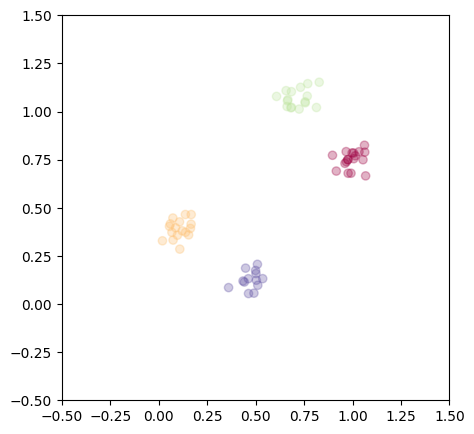

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y,
              alpha=0.3,
              cmap=plt.cm.Spectral)
  plt.xlim(-0.5,1.5)
  plt.ylim(-0.5,1.5)

def plotHyperplan(vector, intercept=0):
  xs = np.array([0,1])
  ys = -(vector[0]*xs + intercept)/vector[1]
  plt.plot(xs, ys, '-')

def makeMulticlassDataset(n=20, n_classes=4):
  X, y = make_blobs(
      n_samples=n*n_classes,
      centers=n_classes,
      n_features=2,
      center_box=(-0.2,1.2),
      cluster_std=0.05
  )
  return X, y

X, y = makeMulticlassDataset()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
plotDataset(X_train, y_train)
plt.show()

In [24]:
def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

def sign(a):
  return (a>=0)*2-1

from abc import ABC, abstractstaticmethod

class Cost(ABC):
  @abstractstaticmethod
  def getCost(y, ypred):
    pass
  @abstractstaticmethod
  def getGradient(y, ypred, X):
    pass

class WidrowHoff(Cost):
  @staticmethod
  def getCost(y, ypred):
    return 0.5* ((y-ypred)**2)
  @staticmethod
  def getGradient(y, ypred, X):
    return X.T @ (y-ypred)

from abc import ABC, abstractmethod

class TrainingAlgorithm(ABC):
  @abstractmethod
  def getW(self, X, y):
    pass

class GradientDescent(TrainingAlgorithm):
  def __init__(self, learning_rate=0.005, n_iter=500, cost=WidrowHoff()):
    self.learning_rate = learning_rate
    self.n_iter = n_iter
    self.cost = cost

  def getW(self, X, y):
    w = np.random.uniform(size=X.shape[1])*2-1
    for _ in range(self.n_iter):
      ypred = X @ w
      w += self.learning_rate * self.cost.getGradient(y, ypred, X)
    return w

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

class NeuralNetwork(BaseEstimator, ClassifierMixin):
  def __init__(self, trainingAlgorithm=GradientDescent()):
    self.trainingAlgorithm = trainingAlgorithm

  def fit(self, X, y):
    X = include_bias(X)
    self.w_ = self.trainingAlgorithm.getW(X, y)
    return self

  def predict(self, X):
    X = include_bias(X)
    return np.sign(X @ self.w_)


0.0


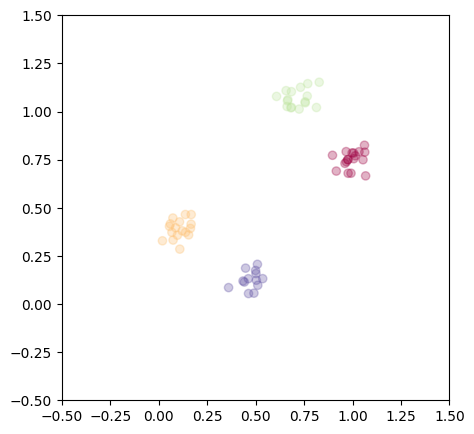

In [26]:
model = NeuralNetwork()
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(accuracy_score(y_train, y_pred))
plotDataset(X_train, y_train)
plotHyperplan(model.w_[1:], model.w_[0])
plt.show()

In [27]:
y_train

array([1, 2, 2, 2, 0, 1, 0, 1, 3, 3, 3, 3, 3, 1, 2, 0, 3, 2, 0, 3, 1, 2,
       2, 3, 1, 0, 0, 3, 2, 1, 1, 3, 1, 2, 3, 2, 0, 0, 1, 0, 0, 2, 1, 2,
       3, 2, 0, 0, 1, 1, 1, 3, 0, 1, 0, 0, 1, 0, 2, 2, 0, 1, 0, 2])

In [28]:
y_hot = np.zeros((y_train.shape[0], 4))
for i in range(y_train.shape[0]):
  y_hot[i, y_train[i]] = 1
# y_hot = y_hot * 2 -1
y_hot

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],


1.0
[[-1.39237786  0.66749021 -1.45524205  0.18013209]
 [ 2.42458768 -2.43604933 -0.90587396  0.91747896]
 [-0.7560207   0.46834682  2.44317074 -2.15563828]]


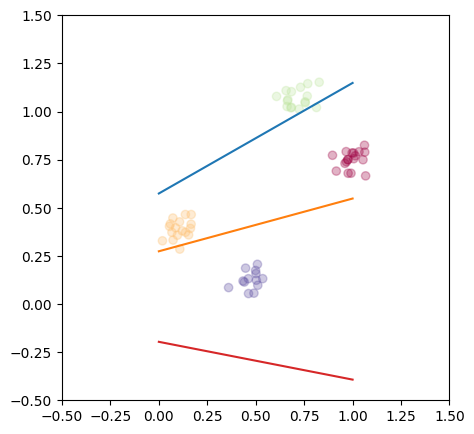

In [39]:
class GradientDescent(TrainingAlgorithm):
  def __init__(self, learning_rate=0.005, n_iter=500, cost=WidrowHoff()):
    self.learning_rate = learning_rate
    self.n_iter = n_iter
    self.cost = cost

  def getW(self, X, y):
    w = np.random.uniform(-1, 1, size=(X.shape[1], y.shape[1]))
    for _ in range(self.n_iter):
      ypred = X @ w
      w += self.learning_rate * self.cost.getGradient(y, ypred, X)
    return w


from sklearn.preprocessing import LabelBinarizer

class NeuralNetwork(BaseEstimator, ClassifierMixin):
  def __init__(self, trainingAlgorithm=GradientDescent()):
    self.trainingAlgorithm = trainingAlgorithm

  def fit(self, X, y):
    self.label_binarizer = LabelBinarizer()
    y = self.label_binarizer.fit_transform(y)
    y = y * 2 -1
    X = include_bias(X)
    self.w_ = self.trainingAlgorithm.getW(X, y)
    return self

  def predict(self, X):
    X = include_bias(X)
    logit = X @ self.w_
    if self.w_.shape[1] == 1:
      return sign(logit)
    return self.label_binarizer.inverse_transform(logit)

model = NeuralNetwork()
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(accuracy_score(y_train, y_pred))
plotDataset(X_train, y_train)
print(model.w_)
for i in range(model.w_.shape[1]):
  plotHyperplan(model.w_[:,i], model.w_[0,i])

1.0
[[-1.39237786  0.66749021 -1.45524205  0.18013209]
 [ 2.42458768 -2.43604933 -0.90587396  0.91747896]
 [-0.7560207   0.46834682  2.44317074 -2.15563828]]


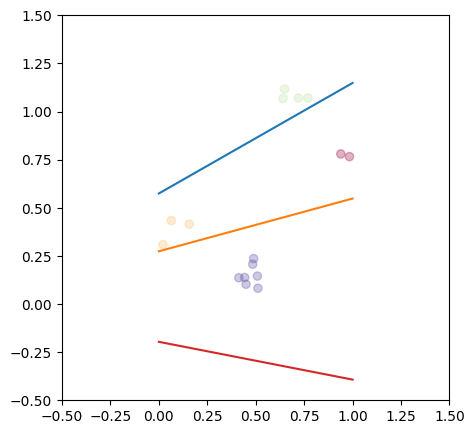

In [40]:
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
plotDataset(X_test, y_test)
print(model.w_)
for i in range(model.w_.shape[1]):
  plotHyperplan(model.w_[:,i], model.w_[0,i])

1.0
[[ 1.29670391 -1.16520202 -0.21710963 -1.91362242]
 [ 0.17251226  1.7048194  -1.55814998 -0.31893058]
 [-3.01408022 -0.31005067  0.72339282  2.5993207 ]]
1.0


[]

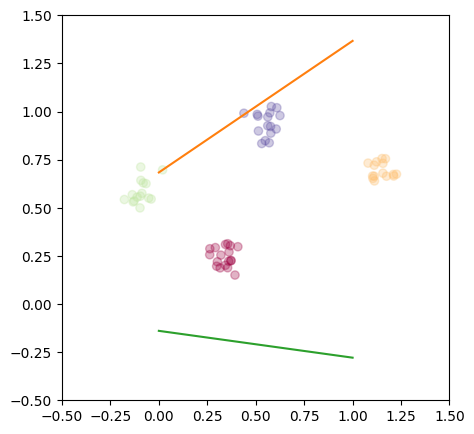

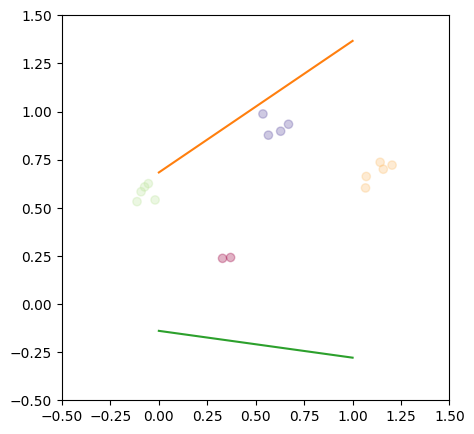

In [49]:
X, y = makeMulticlassDataset()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = NeuralNetwork()
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(accuracy_score(y_train, y_pred))
plotDataset(X_train, y_train)
print(model.w_)
for i in range(model.w_.shape[1]):
  plotHyperplan(model.w_[:,i], model.w_[0,i])
plt.plot()
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
plotDataset(X_test, y_test)
for i in range(model.w_.shape[1]):
  plotHyperplan(model.w_[:,i], model.w_[0,i])
plt.plot()